In [1]:
# Import libraries :

import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
# render figures directly in the notebook :
%matplotlib inline
# render higher resolution images :
plt.style.use('seaborn-v0_8')  # or 'default', 'ggplot', etc.
sns.set_style("whitegrid")

# Seaborn is a Python data visualization library based on matplotlib :
import seaborn as sns 

# Missing data visualization module for Python :
import missingno as msno 
import datetime as dt

In [2]:
airbnb = pd.read_csv('airbnb.csv', index_col = 'Unnamed: 0')

In [3]:
airbnb.head(1)

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","(40.63222, -73.93398)",Private room,45$,10,2018-12-12,0.7,85,4.100954,12.0,0.609432,2018-06-08


In [4]:
airbnb.columns.to_list()

['listing_id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood_full',
 'coordinates',
 'room_type',
 'price',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'availability_365',
 'rating',
 'number_of_stays',
 '5_stars',
 'listing_added']

In [5]:
airbnb.shape

(10019, 16)

- **10019** is the number of observation of our dataset
- **16** is the number of column

 >- ## **Diagnosing data cleaning problems using simple pandas**

In [6]:
#info of dataset
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10019 entries, 0 to 10018
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   listing_id          10019 non-null  int64  
 1   name                10014 non-null  object 
 2   host_id             10019 non-null  int64  
 3   host_name           10017 non-null  object 
 4   neighbourhood_full  10019 non-null  object 
 5   coordinates         10019 non-null  object 
 6   room_type           10019 non-null  object 
 7   price               9781 non-null   object 
 8   number_of_reviews   10019 non-null  int64  
 9   last_review         7944 non-null   object 
 10  reviews_per_month   7944 non-null   float64
 11  availability_365    10019 non-null  int64  
 12  rating              7944 non-null   float64
 13  number_of_stays     7944 non-null   float64
 14  5_stars             7944 non-null   float64
 15  listing_added       10019 non-null  object 
dtypes: float6

In [7]:
airbnb.describe(include='all')

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
count,1.001900e+04,10014,1.001900e+04,10017,10019,10019,10019,9781,10019.000000,7944,7944.000000,10019.000000,7944.000000,7944.000000,7944.000000,10019
unique,NaN,9919,NaN,4084,198,9997,7,433,NaN,1222,NaN,NaN,NaN,NaN,NaN,1235
top,NaN,New york Multi-unit building,NaN,Michael,"Brooklyn, Bedford-Stuyvesant","(40.73652, -73.95236)",Entire home/apt,150$,NaN,2019-06-23,NaN,NaN,NaN,NaN,NaN,2018-12-18
freq,NaN,5,NaN,89,777,2,5120,416,NaN,283,NaN,NaN,NaN,NaN,NaN,283
mean,1.927634e+07,NaN,6.795923e+07,NaN,NaN,NaN,NaN,NaN,22.459727,NaN,1.353894,112.284260,4.014458,33.991541,0.718599,NaN
std,1.095056e+07,NaN,7.863106e+07,NaN,NaN,NaN,NaN,NaN,43.173896,NaN,1.615380,131.636043,0.575064,56.089279,0.079978,NaN
min,3.831000e+03,NaN,2.787000e+03,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.010000,0.000000,3.000633,1.200000,0.600026,NaN
25%,9.674772e+06,NaN,7.910880e+06,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,0.200000,0.000000,3.520443,3.600000,0.655576,NaN
50%,2.007030e+07,NaN,3.165167e+07,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,0.710000,44.000000,4.027965,10.800000,0.709768,NaN
75%,2.933864e+07,NaN,1.074344e+08,NaN,NaN,NaN,NaN,NaN,22.000000,NaN,2.000000,226.000000,4.516378,38.400000,0.763978,NaN


In [8]:
# caculating missing value
missing_airbnb = airbnb.isna().sum().reset_index().rename(columns={0: 'Count'})

In [9]:
missing_airbnb[missing_airbnb['Count']>0].sort_values(by='Count',ascending=False)

,index,Count
9,last_review,2075
13,number_of_stays,2075
12,rating,2075
10,reviews_per_month,2075
14,5_stars,2075
7,price,238
1,name,5
3,host_name,2


In [10]:
missing_airbnb['Count'].sum()

np.int64(10620)

- **10620** missing values

In [11]:
airbnb.nunique().reset_index().rename(columns={0: 'Count'})

,index,Count
0,listing_id,9999
1,name,9919
2,host_id,8921
3,host_name,4084
4,neighbourhood_full,198
5,coordinates,9997
6,room_type,7
7,price,433
8,number_of_reviews,271
9,last_review,1222


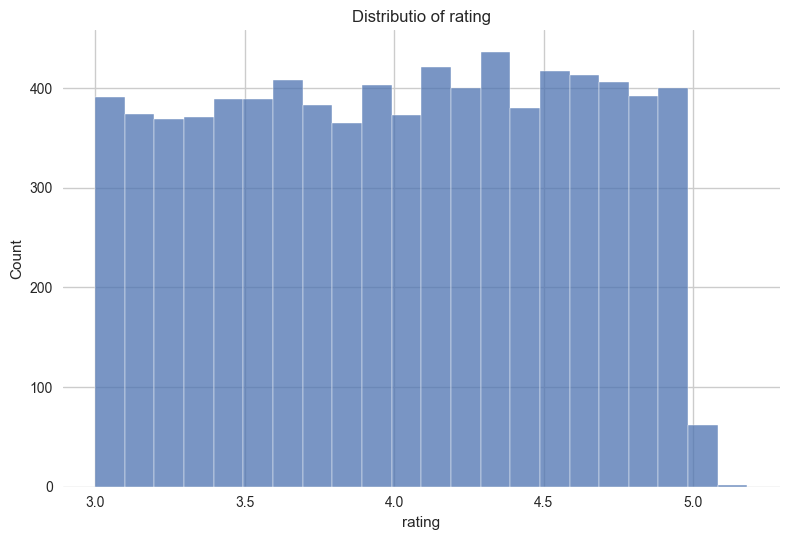

In [12]:
sns.histplot(airbnb['rating'])
plt.title('Distributio of rating')
plt.tight_layout()
plt.show()

In [13]:
#how many different types of room we have 

room_type = airbnb['room_type'].value_counts(normalize=True).reset_index()
room_type

,room_type,proportion
0,Entire home/apt,0.511029
1,Private room,0.447849
2,Shared room,0.015471
3,Private,0.008883
4,Shared room,0.007087
5,home,0.006587
6,PRIVATE ROOM,0.003094


**95%** of Room are Spartment and private room

In [14]:
airbnb.head()

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","(40.63222, -73.93398)",Private room,45$,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","(40.78761, -73.96862)",Entire home/apt,135$,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","(40.7007, -73.99517)",Entire home/apt,150$,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","(40.79169, -73.97498)",Entire home/apt,86$,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","(40.71884, -73.98354)",Private room,160$,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23


In [15]:

# Removing "(" and ")" from coordinates 

airbnb['coordinates']=airbnb['coordinates'].str.replace(")","")
airbnb['coordinates']=airbnb['coordinates'].str.replace("(","")

In [16]:
airbnb['latitude']  = airbnb['coordinates'].str.split("," , expand=True).get(0)
airbnb['longitude']  = airbnb['coordinates'].str.split("," , expand=True).get(1)


In [17]:
# Spliting coordinates column into two new columns : lat_long[0] and lat_long[1] 

airbnb.head(2)

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","40.63222, -73.93398",Private room,45$,10,2018-12-12,0.7,85,4.100954,12.0,0.609432,2018-06-08,40.63222,-73.93398
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","40.78761, -73.96862",Entire home/apt,135$,1,2019-06-30,1.0,145,3.367600,1.2,0.746135,2018-12-25,40.78761,-73.96862


In [18]:
airbnb['latitude']=airbnb['latitude'].astype('float')
airbnb['longitude']=airbnb['longitude'].astype('float')

In [19]:
airbnb.dtypes

listing_id              int64
name                   object
host_id                 int64
host_name              object
neighbourhood_full     object
coordinates            object
room_type              object
price                  object
number_of_reviews       int64
last_review            object
reviews_per_month     float64
availability_365        int64
rating                float64
number_of_stays       float64
5_stars               float64
listing_added          object
latitude              float64
longitude             float64
dtype: object

In [20]:
airbnb.drop('coordinates', axis = 1, inplace = True)

In [21]:
airbnb['price']=airbnb['price'].str.strip('$')

In [22]:
airbnb['price'].head(5)

0     45
1    135
2    150
3     86
4    160
Name: price, dtype: object

In [23]:

# Convert price to float
airbnb['price'] = airbnb['price'].astype('float')

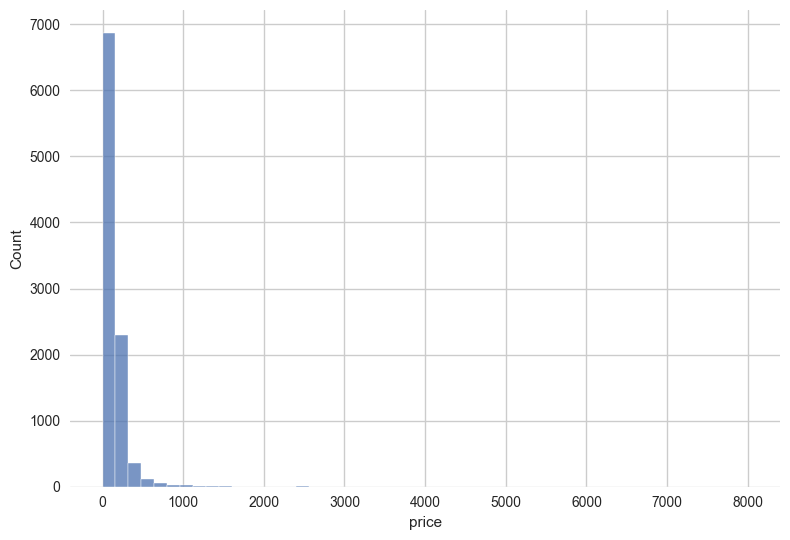

In [24]:
sns.histplot(airbnb['price'], bins=50)
plt.tight_layout()
plt.show()

In [25]:

# Printing header of two columns :
airbnb[['listing_added', 'last_review']].head()

,listing_added,last_review
0,2018-06-08,2018-12-12
1,2018-12-25,2019-06-30
2,2018-08-15,NaN
3,2017-03-20,2017-09-23
4,2020-10-23,2019-06-12


In [26]:
airbnb['listing_added'] = pd.to_datetime(airbnb['listing_added'] , format="%Y-%m-%d")
airbnb['last_review'] = pd.to_datetime(airbnb['last_review'] , format="%Y-%m-%d")

In [27]:

# Printing header of two columns :
airbnb[['listing_added', 'last_review']].head().dtypes

listing_added    datetime64[ns]
last_review      datetime64[ns]
dtype: object

In [28]:
airbnb['room_type']= airbnb['room_type'].str.strip().str.lower()

In [29]:
airbnb['room_type']

0           private room
1        entire home/apt
2        entire home/apt
3        entire home/apt
4           private room
              ...       
10014    entire home/apt
10015    entire home/apt
10016    entire home/apt
10017    entire home/apt
10018       private room
Name: room_type, Length: 10019, dtype: object

In [30]:
mappings = {'private room': 'Private Room', 
            'private': 'Private Room',
            'entire home/apt': 'Entire place',
            'shared room': 'Shared room',
            'home': 'Entire place'}

# Replacing values and collapsing data :
airbnb['room_type'] = airbnb['room_type'].replace(mappings)
airbnb['room_type'].head(10)

0    Private Room
1    Entire place
2    Entire place
3    Entire place
4    Private Room
5    Entire place
6    Entire place
7    Entire place
8    Entire place
9    Entire place
Name: room_type, dtype: object

In [31]:
borough_neighbourhood=airbnb['neighbourhood_full'].str.split(",", expand=True)

In [32]:

# Creating borough and neighbourhood columns :
airbnb['borough'] = borough_neighbourhood[0]
airbnb['neighbourhood'] = borough_neighbourhood[1]

# Printing header of the recently created columns :
airbnb[['neighbourhood_full', 'borough', 'neighbourhood']].head()

,neighbourhood_full,borough,neighbourhood
0,"Brooklyn, Flatlands",Brooklyn,Flatlands
1,"Manhattan, Upper West Side",Manhattan,Upper West Side
2,"Brooklyn, Brooklyn Heights",Brooklyn,Brooklyn Heights
3,"Manhattan, Upper West Side",Manhattan,Upper West Side
4,"Manhattan, Lower East Side",Manhattan,Lower East Side


In [33]:
airbnb.drop(columns='neighbourhood_full' , inplace=True)

In [34]:
airbnb.head(2)

,listing_id,name,host_id,host_name,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,Private Room,45.0,10,2018-12-12,0.7,85,4.100954,12.0,0.609432,2018-06-08,40.63222,-73.93398,Brooklyn,Flatlands
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,Entire place,135.0,1,2019-06-30,1.0,145,3.367600,1.2,0.746135,2018-12-25,40.78761,-73.96862,Manhattan,Upper West Side


In [35]:
# Striping white space from neighbourhood column :
airbnb['neighbourhood'] = airbnb['neighbourhood'].str.strip()

<Axes: ylabel='Frequency'>

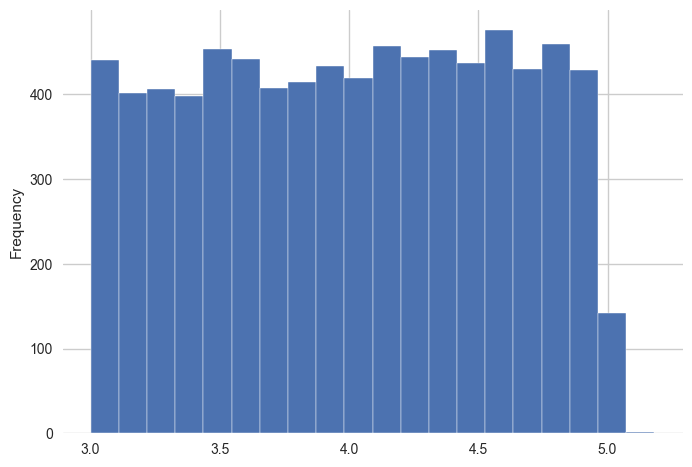

In [36]:
airbnb['rating'].plot(kind='hist' ,bins=20)

In [37]:

# Isolating rows of rating > 5.0
airbnb[airbnb['rating'] > 5.0]

,listing_id,name,host_id,host_name,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood
1925,36411407,Brand new 1 bedroom steps from Soho!,33917435,Mike,Entire place,150.0,1,2019-07-06,1.0,13,5.017040,1.2,0.870161,2018-12-31,40.71825,-73.99019,Manhattan,Lower East Side
6732,36390226,Comfortable clean Bedstuy private room,267932490,Angela,Private Room,45.0,2,2019-07-08,2.0,14,5.087091,2.4,0.950339,2019-01-02,40.69551,-73.93951,Brooklyn,Bedford-Stuyvesant
8821,36413632,Spacious 2BR in Beautiful Brooklyn Heights,6608220,Matt,Entire place,550.0,1,2019-07-07,1.0,230,5.181114,1.2,0.805418,2019-01-01,40.69827,-73.99649,Brooklyn,Brooklyn Heights


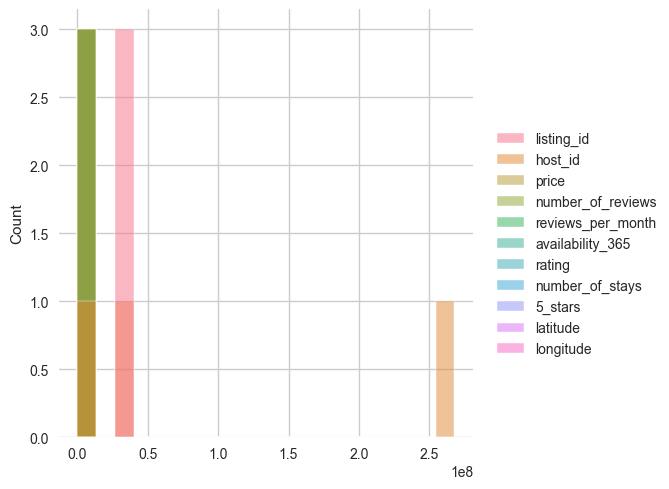

In [38]:
sns.displot(airbnb[airbnb['rating'] > 5.0], bins = 20)
plt.show()

In [39]:

# Droping these rows and make sure we have effected changes :
airbnb.drop(airbnb[airbnb['rating'] > 5.0].index, inplace = True)

# Making sure the rows had been deleted
airbnb[airbnb['rating'] > 5.0].info

<bound method DataFrame.info of Empty DataFrame
Columns: [listing_id, name, host_id, host_name, room_type, price, number_of_reviews, last_review, reviews_per_month, availability_365, rating, number_of_stays, 5_stars, listing_added, latitude, longitude, borough, neighbourhood]
Index: []>

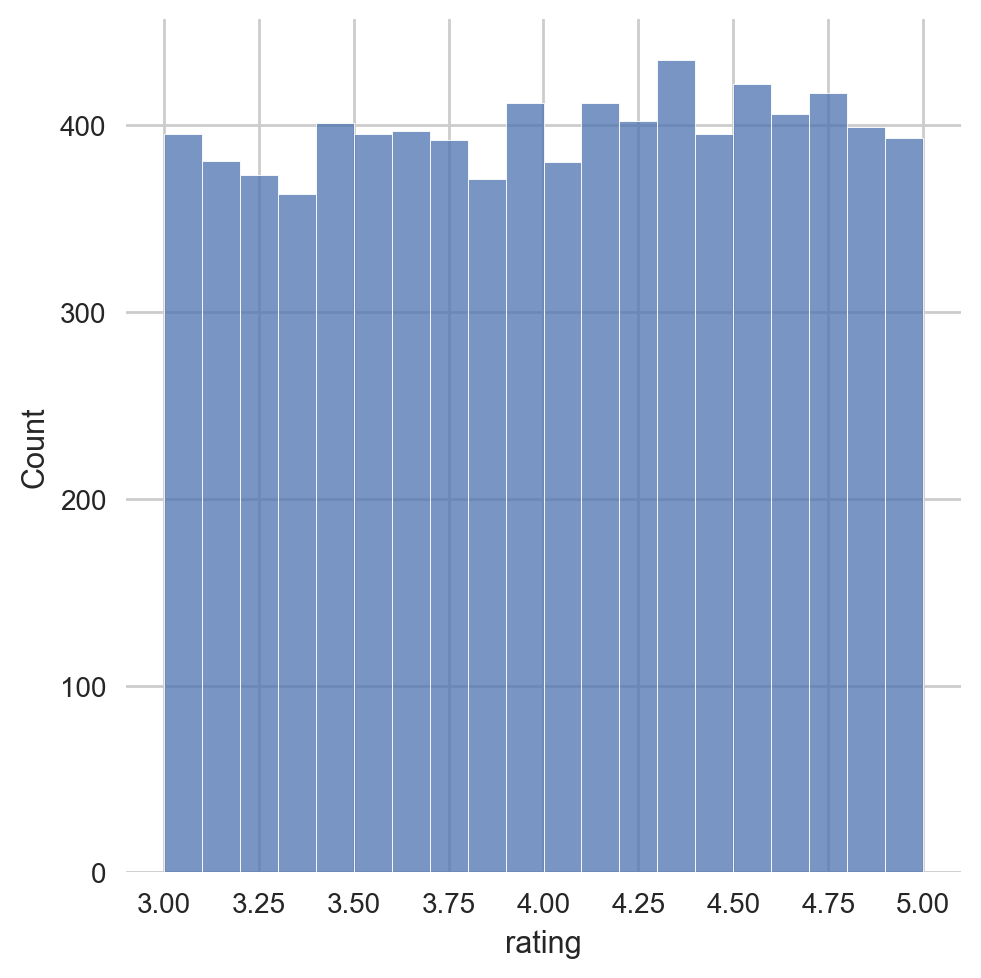

In [40]:
%config InlineBackend.figure_format = 'retina'
sns.displot(airbnb['rating'], bins = 20)
plt.show()

In [41]:
airbnb['rating'].max()

np.float64(4.999561104773598)

<Axes: >

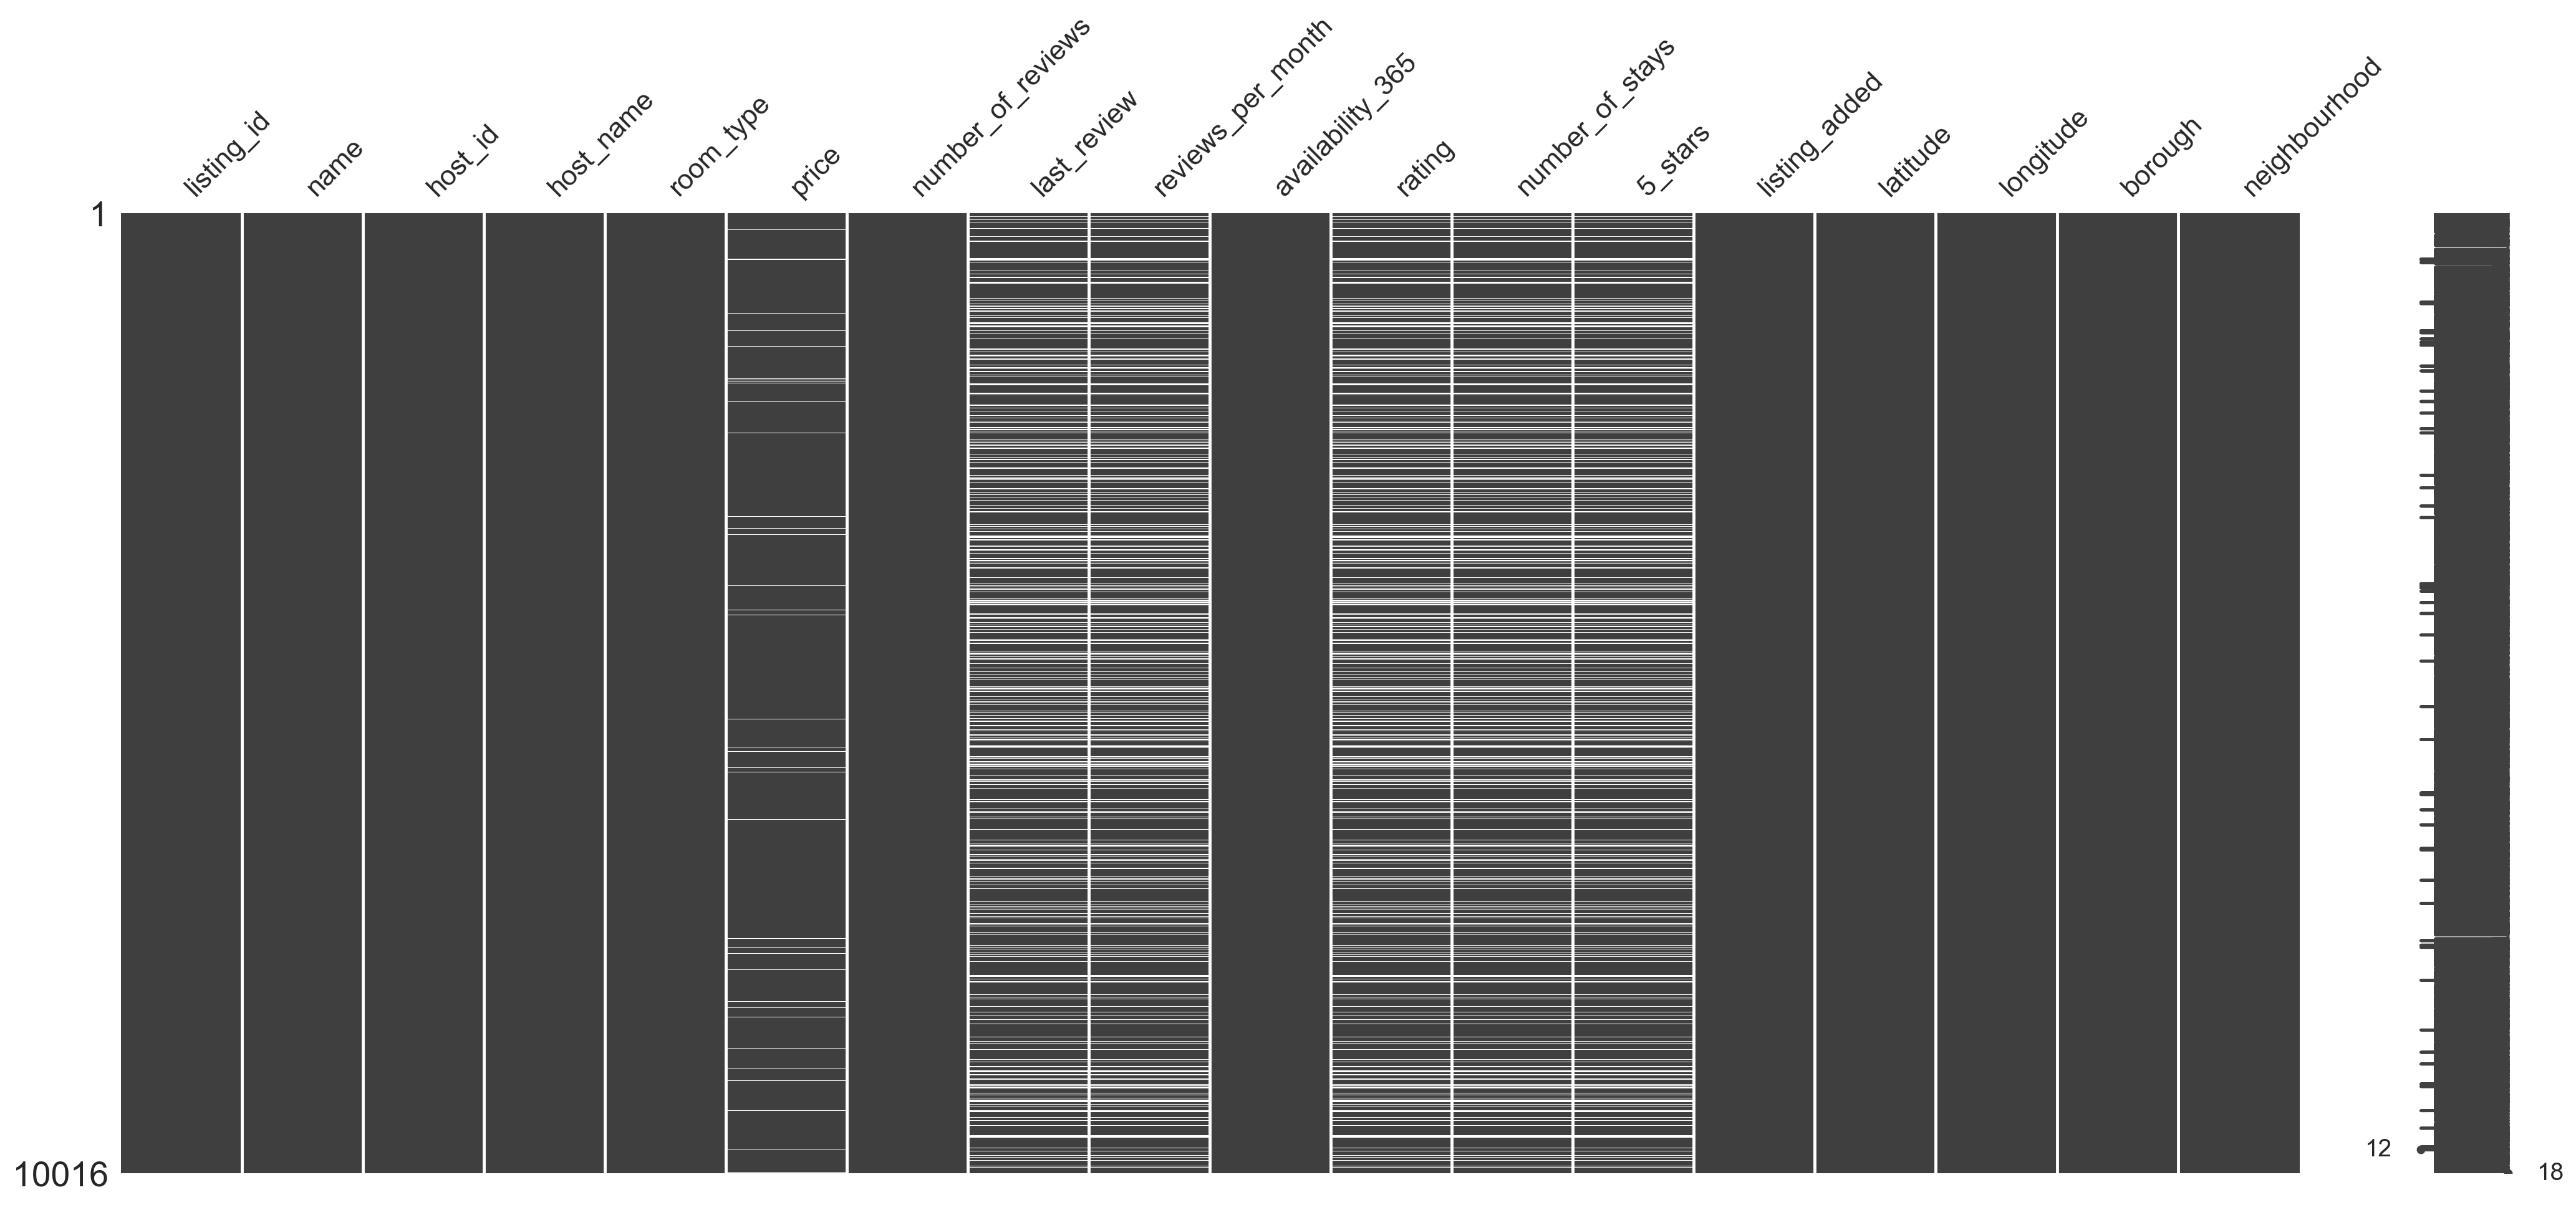

In [42]:
msno.matrix(airbnb)

<Axes: >

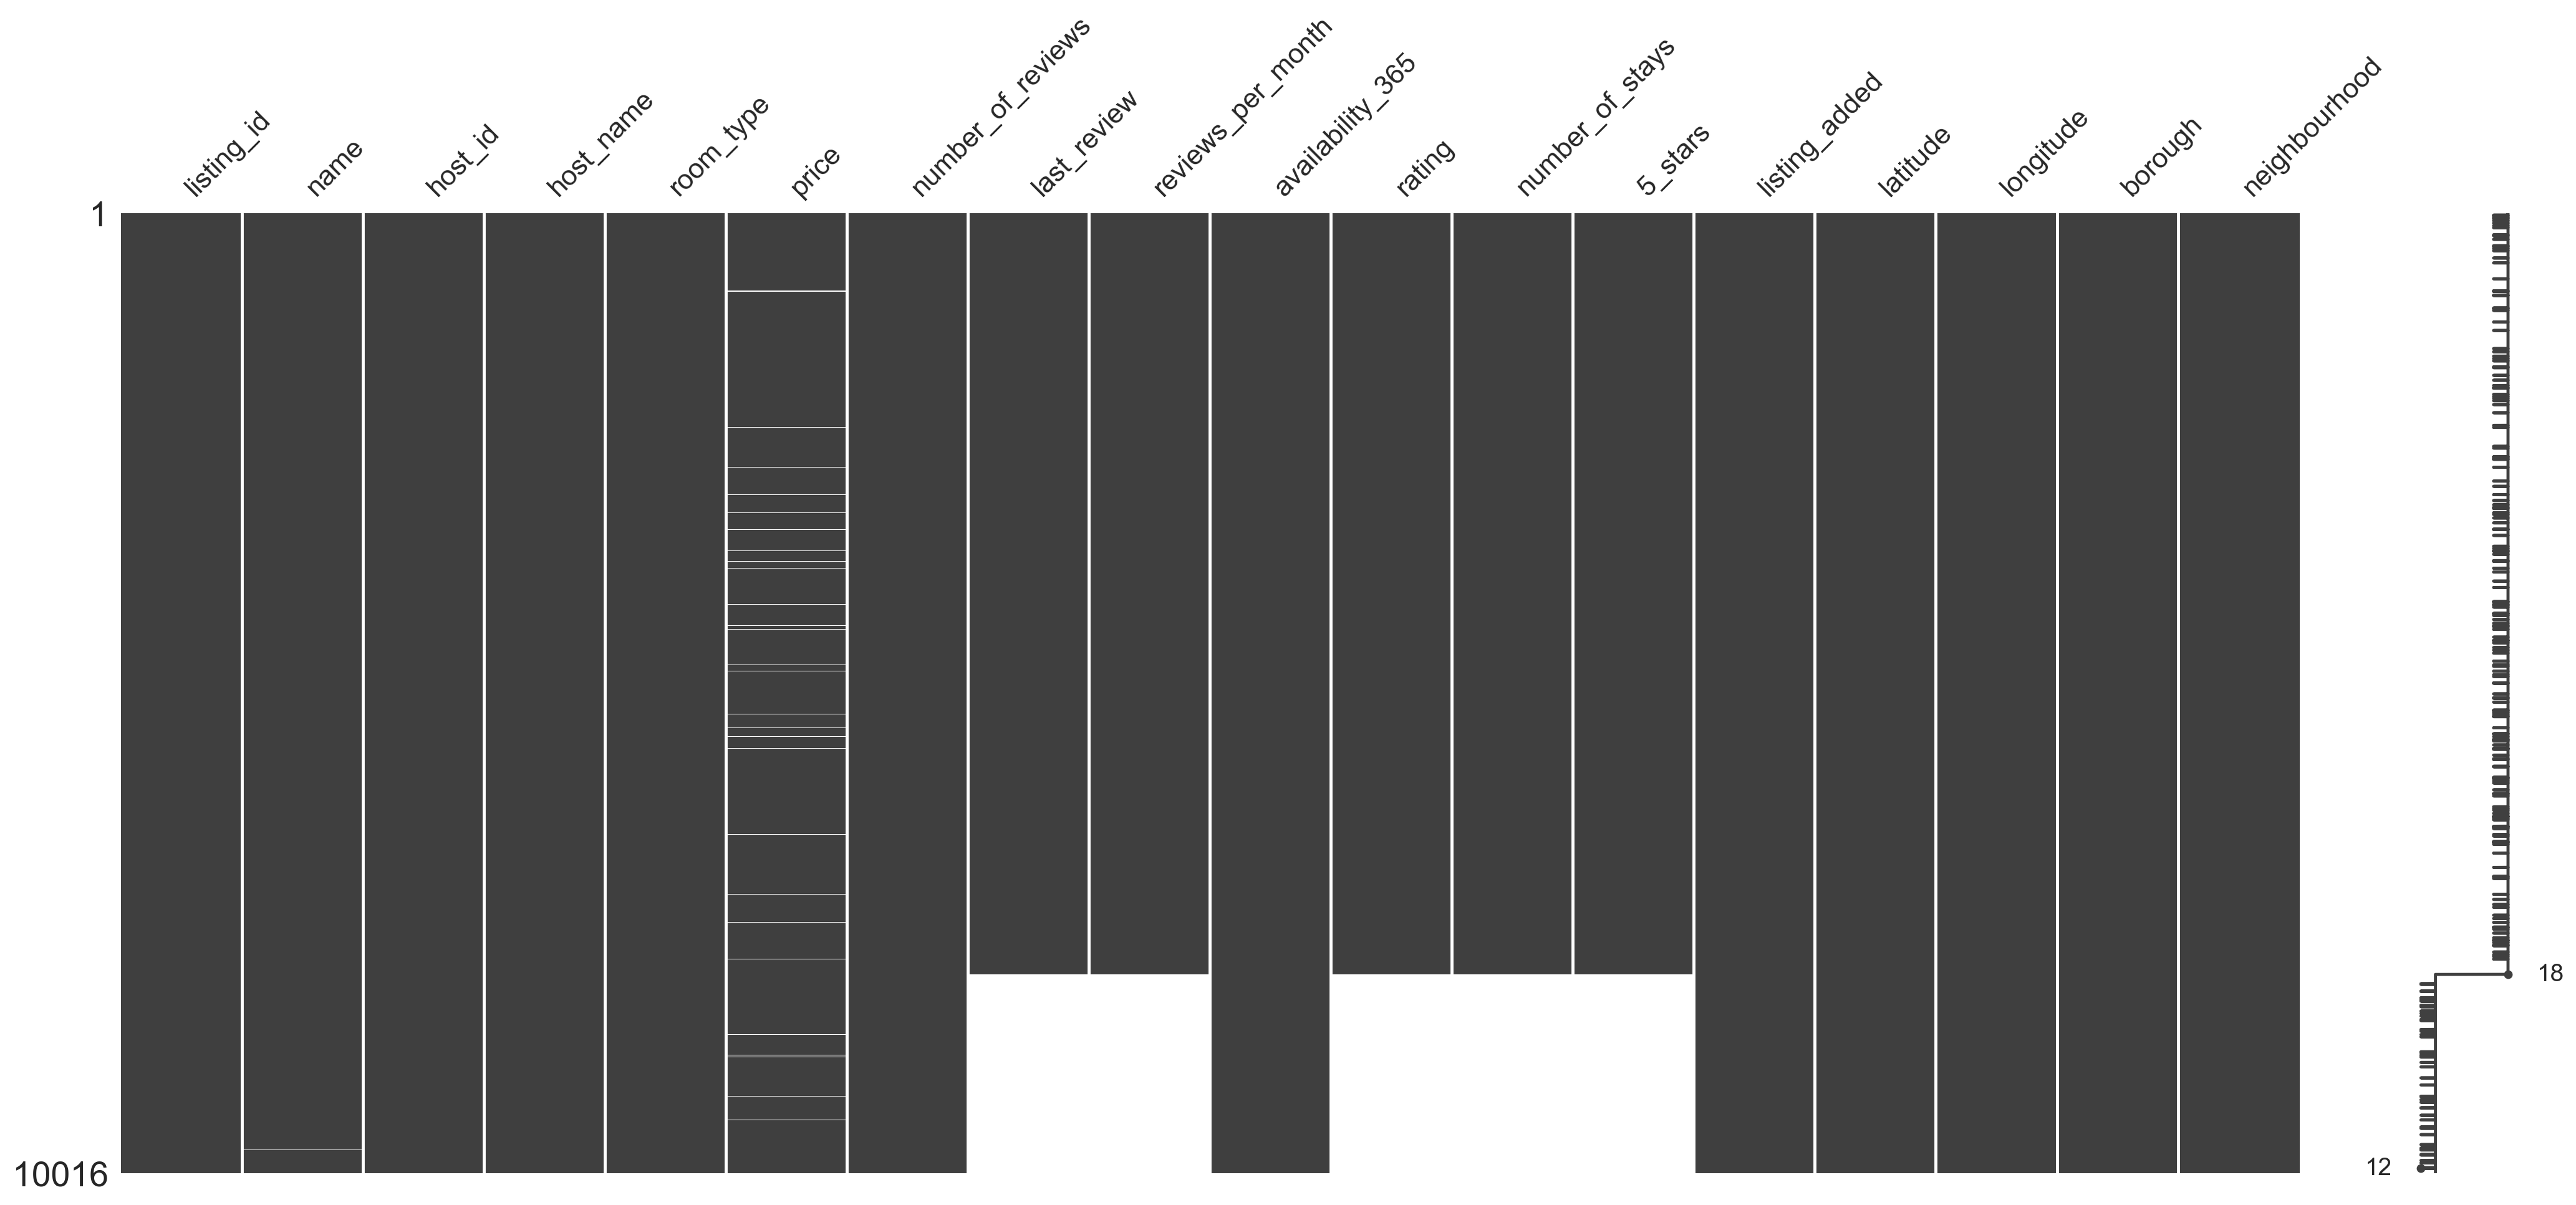

In [43]:
msno.matrix(airbnb.sort_values(by='rating'))

<Axes: >

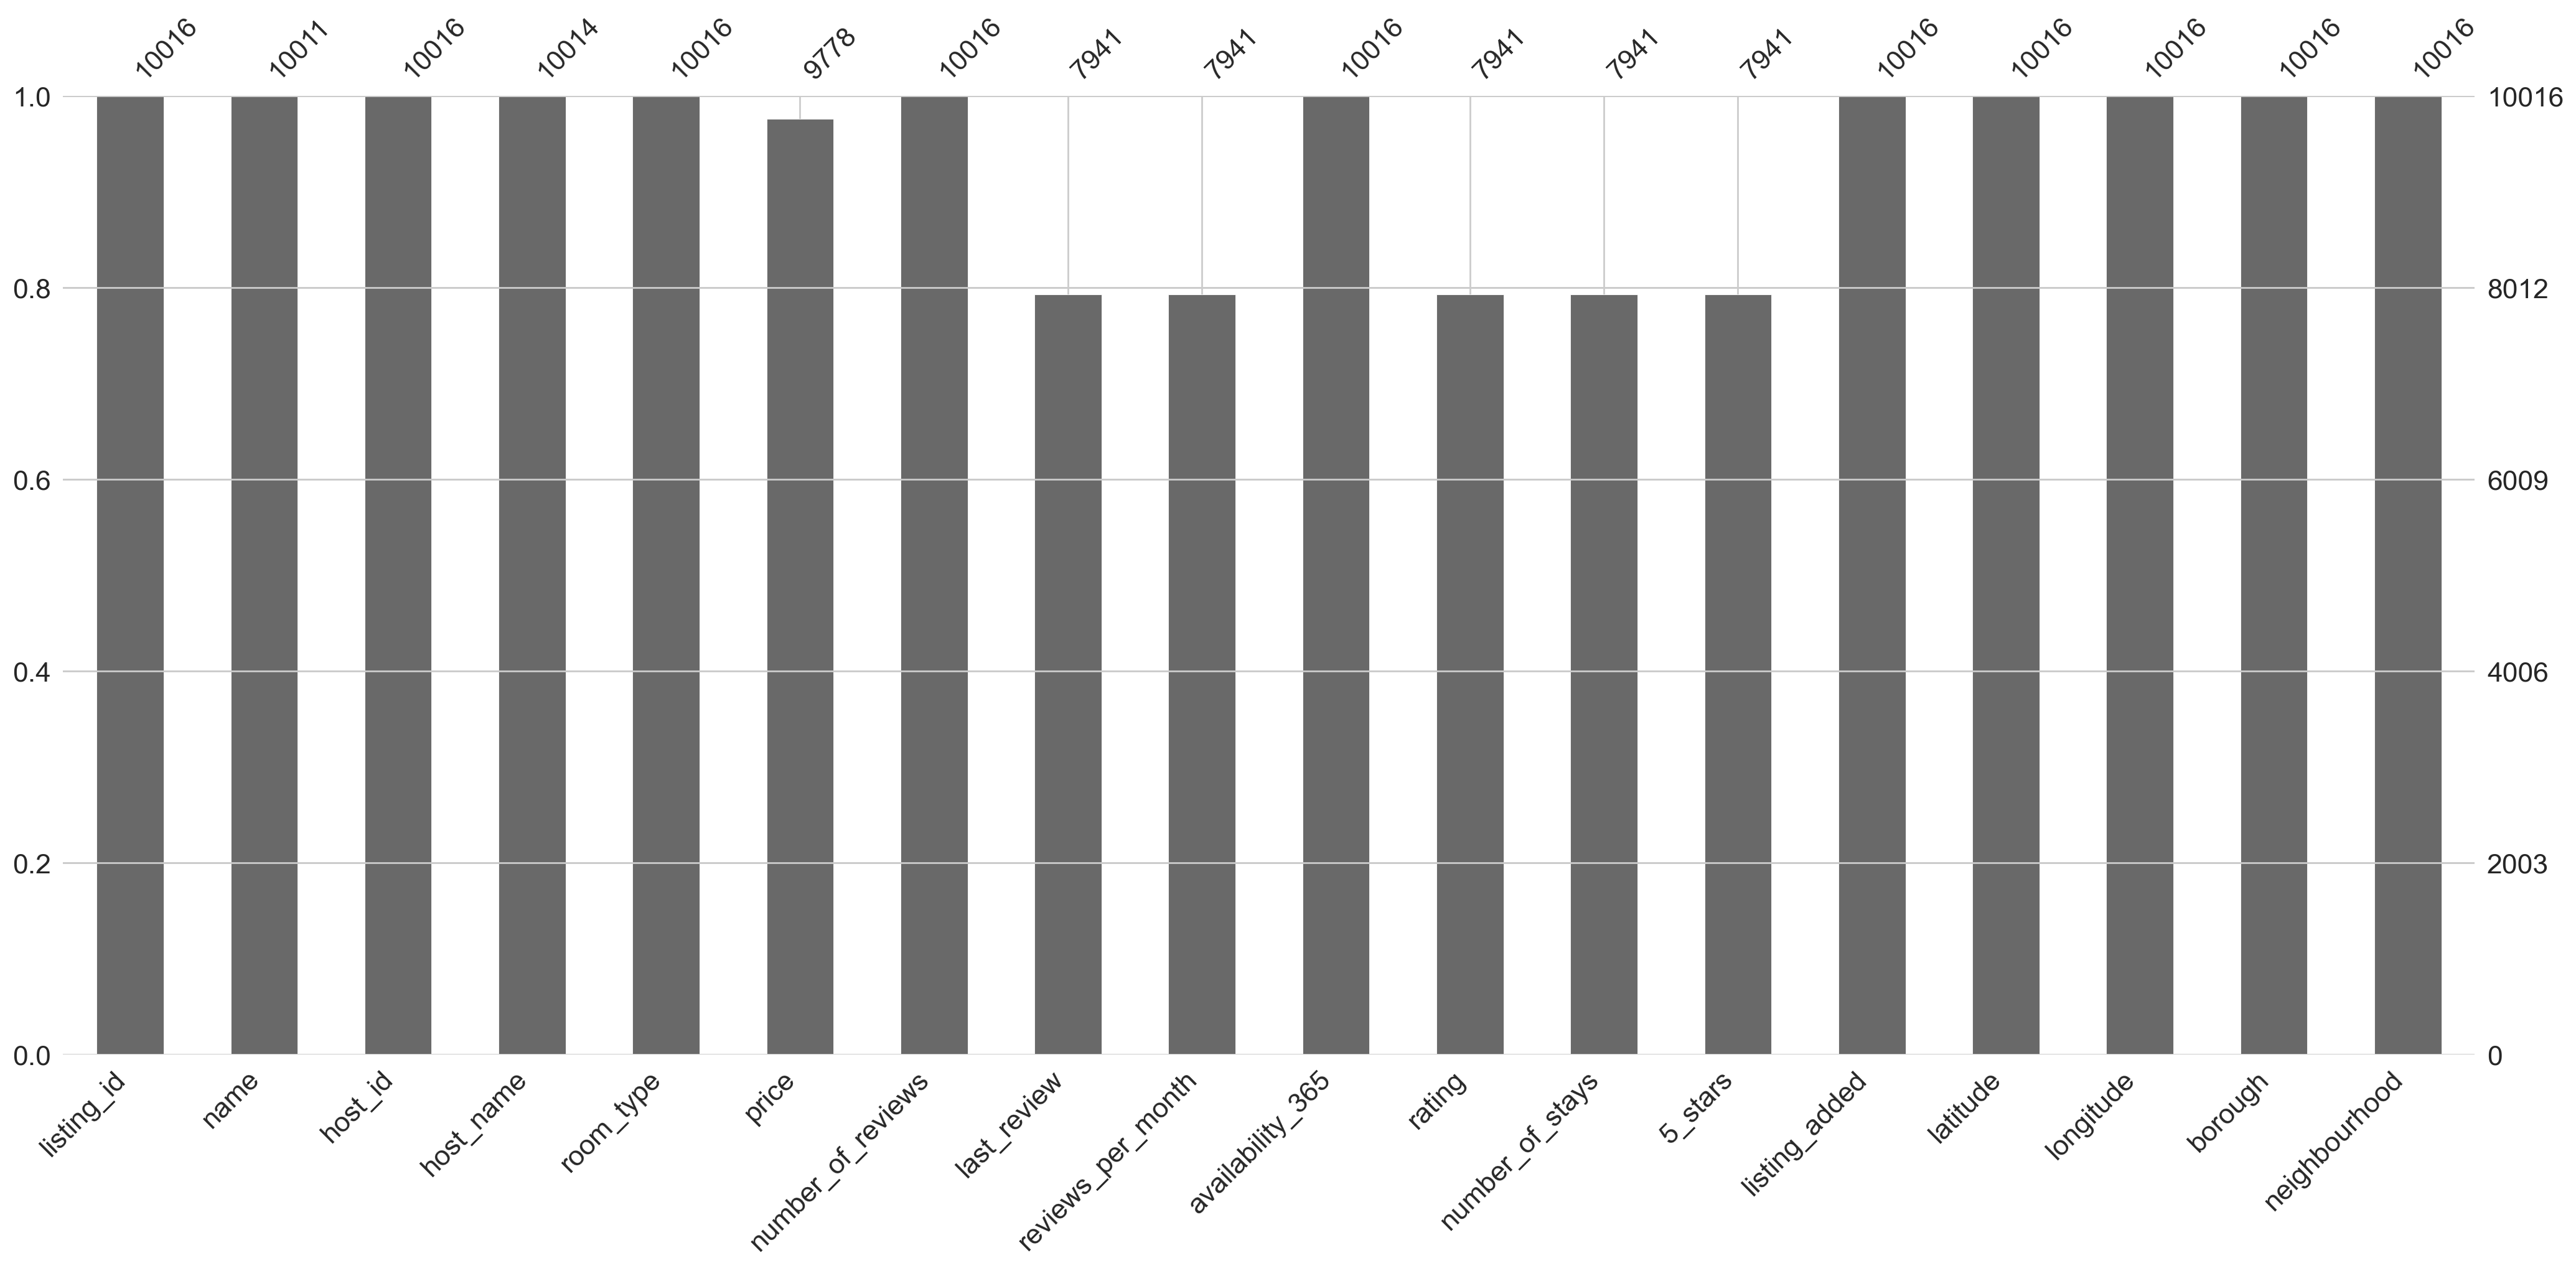

In [44]:
msno.bar(airbnb)

In [45]:
# Understanding DataFrame with missing values in rating, number_of_stays, 5_stars, reviews_per_month :
airbnb[airbnb['rating'].isna()].describe()

,listing_id,host_id,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude
count,2.075000e+03,2.075000e+03,2028.000000,2075.0,0,0.0,2075.000000,0.0,0.0,0.0,2075,2075.000000,2075.000000
mean,2.274238e+07,8.022455e+07,191.553748,0.0,NaT,NaN,104.531566,NaN,NaN,NaN,2018-06-08 17:01:31.951807232,40.732074,-73.956771
min,6.358800e+04,1.475100e+04,0.000000,0.0,NaT,NaN,0.000000,NaN,NaN,NaN,2018-02-03 00:00:00,40.527000,-74.209410
25%,1.232923e+07,1.224305e+07,70.000000,0.0,NaT,NaN,0.000000,NaN,NaN,NaN,2018-04-05 00:00:00,40.697845,-73.985185
50%,2.345182e+07,4.040116e+07,120.000000,0.0,NaT,NaN,7.000000,NaN,NaN,NaN,2018-06-05 00:00:00,40.727790,-73.960940
75%,3.400364e+07,1.333498e+08,205.250000,0.0,NaT,NaN,211.000000,NaN,NaN,NaN,2018-08-13 00:00:00,40.763480,-73.939540
max,3.648724e+07,2.741034e+08,5250.000000,0.0,NaT,NaN,365.000000,NaN,NaN,NaN,2018-10-17 00:00:00,40.911690,-73.727310
std,1.123730e+07,8.663163e+07,316.186639,0.0,NaN,NaN,138.266525,NaN,NaN,NaN,NaN,0.051168,0.041065


In [46]:

# Imputing missing data :
airbnb = airbnb.fillna({'reviews_per_month':0,
                        'number_of_stays':0,
                        '5_stars':0} )

In [47]:
is_rated =np.where(airbnb['rating'].isna()==True,0,1)
airbnb['is_rated']=is_rated
airbnb.isna().sum()

listing_id              0
name                    5
host_id                 0
host_name               2
room_type               0
price                 238
number_of_reviews       0
last_review          2075
reviews_per_month       0
availability_365        0
rating               2075
number_of_stays         0
5_stars                 0
listing_added           0
latitude                0
longitude               0
borough                 0
neighbourhood           0
is_rated                0
dtype: int64

In [48]:
# Investigating DataFrame with missing values in price :
airbnb[airbnb['price'].isna()].count()

listing_id           238
name                 238
host_id              238
host_name            238
room_type            238
price                  0
number_of_reviews    238
last_review          191
reviews_per_month    238
availability_365     238
rating               191
number_of_stays      238
5_stars              238
listing_added        238
latitude             238
longitude            238
borough              238
neighbourhood        238
is_rated             238
dtype: int64

In [49]:

# Investigating DataFrame with missing values in price :
airbnb[~airbnb['price'].isna()].count()

listing_id           9778
name                 9773
host_id              9778
host_name            9776
room_type            9778
price                9778
number_of_reviews    9778
last_review          7750
reviews_per_month    9778
availability_365     9778
rating               7750
number_of_stays      9778
5_stars              9778
listing_added        9778
latitude             9778
longitude            9778
borough              9778
neighbourhood        9778
is_rated             9778
dtype: int64

(0.0, 700.0)

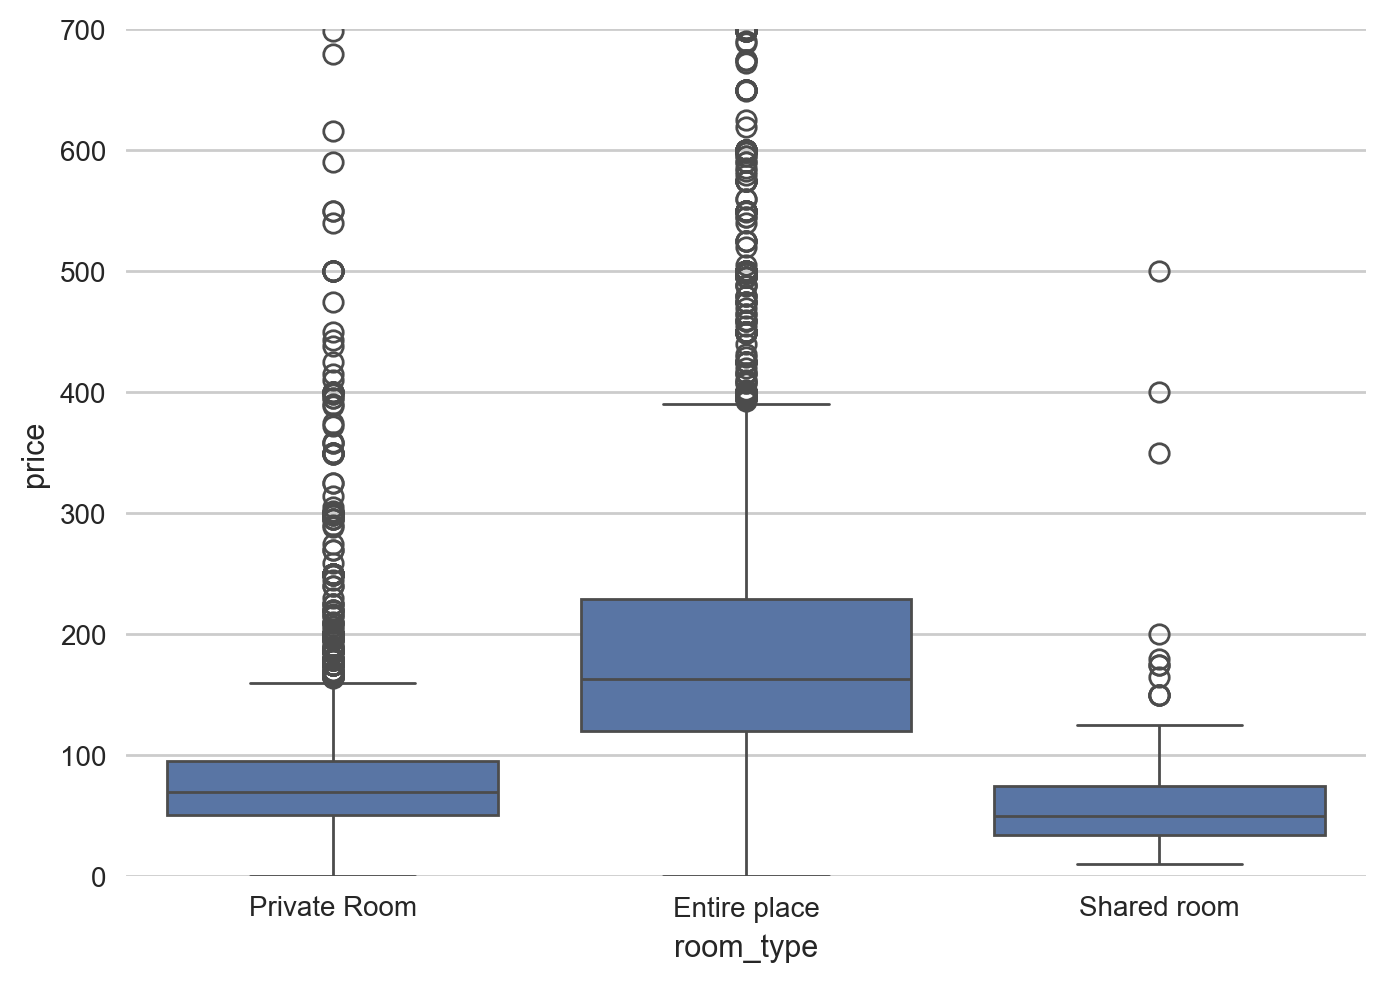

In [50]:
sns.boxplot(x='room_type', y='price',data = airbnb)
plt.ylim(0,700)

In [51]:
fig = px.box(x = airbnb['room_type'], y = airbnb['price'])
fig.show()

In [52]:

# Getting median price per room_type :
airbnb.groupby('room_type')['price'].median()

room_type
Entire place    163.0
Private Room     70.0
Shared room      50.0
Name: price, dtype: float64

In [53]:
# Imputing price based on conditions :
airbnb.loc[(airbnb['price'].isna()) & (airbnb['room_type'] == 'Entire place'), 'price'] = 163.0
airbnb.loc[(airbnb['price'].isna()) & (airbnb['room_type'] == 'Private Room'), 'price'] = 70.0
airbnb.loc[(airbnb['price'].isna()) & (airbnb['room_type'] == 'Shared Room'), 'price'] = 50.0

In [54]:

airbnb[airbnb['price'].isna()]

,listing_id,name,host_id,host_name,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood,is_rated
508,13974200,"Sunny, Pre-War Brooklyn Share",77317167,Stacey Rae,Shared room,NaN,5,2017-10-01,0.15,0,4.752003,6.0,0.658378,2017-03-28,40.65126,-73.96388,Brooklyn,Flatbush,1
1043,33431709,Shared apartment by the Central Park,251852817,Owen,Shared room,NaN,17,2019-06-30,5.10,72,4.683608,20.4,0.917779,2018-12-25,40.80073,-73.94328,Manhattan,East Harlem,1
2086,36118872,A Cozy Bed Dream in Manhattan,178720348,Mingmei,Shared room,NaN,0,NaT,0.00,34,NaN,0.0,0.000000,2018-03-28,40.81851,-73.95670,Manhattan,Harlem,0
3353,21568943,Shareroom in Midtown Manhattan 1or2 beds Avail...,156246842,Sandra,Shared room,NaN,9,2018-08-01,0.45,0,4.382015,10.8,0.634106,2018-01-26,40.76140,-73.98682,Manhattan,Hell's Kitchen,1
3909,30950573,Brooklyn 3 persons shared room close to subway,17706542,Sergey,Shared room,NaN,0,NaT,0.00,342,NaN,0.0,0.000000,2018-09-25,40.69190,-73.90626,Brooklyn,Bushwick,0
8212,7711899,FEMALE ONLY 'Heaven'PrivateBed/SharedSpace w/Wifi,40509550,Denise,Shared room,NaN,14,2018-11-01,0.30,363,4.226222,16.8,0.680988,2018-04-28,40.84805,-73.94209,Manhattan,Washington Heights,1
9793,6155877,Solo traveler oasis,18248926,Yana,Shared room,NaN,84,2019-06-15,2.26,347,4.086250,100.8,0.601364,2018-12-10,40.82434,-73.94816,Manhattan,Harlem,1


In [55]:

# Doing some sanity checks on date data :
today = dt.date.today()

In [56]:
today

datetime.date(2026, 6, 19)

In [57]:
airbnb[airbnb['last_review'].dt.date > today]

,listing_id,name,host_id,host_name,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood,is_rated


In [58]:

# Are there any listings with listing_added > last_review
inconsistent_dates = airbnb[airbnb['listing_added'].dt.date > airbnb['last_review'].dt.date]
inconsistent_dates

,listing_id,name,host_id,host_name,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood,is_rated
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,Private Room,160.0,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23,40.71884,-73.98354,Manhattan,Lower East Side,1
50,20783900,Marvelous Manhattan Marble Hill Private Suites,148960265,Randy,Private Room,93.0,7,2018-10-06,0.32,0,4.868036,8.4,0.609263,2020-02-17,40.87618,-73.91266,Manhattan,Marble Hill,1
60,1908852,Oversized Studio By Columbus Circle,684629,Alana,Entire place,189.0,7,2016-05-06,0.13,0,4.841204,8.4,0.725995,2017-09-17,40.77060,-73.98919,Manhattan,Upper West Side,1
124,28659894,Private bedroom in prime Bushwick! Near Trains!!!,216235179,Nina,Private Room,55.0,4,2019-04-12,0.58,358,4.916252,4.8,0.703117,2020-08-23,40.69988,-73.92072,Brooklyn,Bushwick,1
511,33619855,Modern & Spacious in trendy Crown Heights,253354074,Yehudis,Entire place,150.0,6,2019-05-27,2.50,148,3.462432,7.2,0.610929,2020-10-07,40.66387,-73.93840,Brooklyn,Crown Heights,1
521,25317793,Awesome Cozy Room in The Heart of Sunnyside!,136406167,Kara,Private Room,65.0,22,2019-06-11,1.63,131,4.442485,26.4,0.722388,2020-10-22,40.74090,-73.92696,Queens,Sunnyside,1


In [59]:
duplicates = airbnb.duplicated(subset='listing_id'  , keep = False)

print(duplicates)

0        False
1        False
2        False
3        False
4        False
         ...  
10014    False
10015    False
10016    False
10017    False
10018    False
Length: 10016, dtype: bool


In [60]:
airbnb[duplicates].sort_values('listing_id')

,listing_id,name,host_id,host_name,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood,is_rated
1145,253806,Loft Suite @ The Box House Hotel,417504,The Box House Hotel,Entire place,199.0,43,2019-07-02,0.47,60,4.620238,51.6,0.861086,2018-12-27,40.73652,-73.95236,Brooklyn,Greenpoint,1
6562,253806,Loft Suite @ The Box House Hotel,417504,The Box House Hotel,Entire place,199.0,43,2019-07-02,0.47,60,4.620238,51.6,0.861086,2018-12-27,40.73652,-73.95236,Brooklyn,Greenpoint,1
5761,2044392,The heart of Williamsburg 2 bedroom,620218,Sarah,Entire place,250.0,0,NaT,0.00,0,NaN,0.0,0.000000,2018-05-24,40.71257,-73.96149,Brooklyn,Williamsburg,0
8699,2044392,The heart of Williamsburg 2 bedroom,620218,Sarah,Entire place,245.0,0,NaT,0.00,0,NaN,0.0,0.000000,2018-08-09,40.71257,-73.96149,Brooklyn,Williamsburg,0
4187,4244242,Best Bedroom in Bedstuy/Bushwick. Ensuite bath...,22023014,BrooklynSleeps,Private Room,73.0,110,2019-06-23,1.96,323,4.962314,132.0,0.809882,2018-12-18,40.69496,-73.93949,Brooklyn,Bedford-Stuyvesant,1
2871,4244242,Best Bedroom in Bedstuy/Bushwick. Ensuite bath...,22023014,BrooklynSleeps,Private Room,70.0,110,2019-06-23,1.96,323,4.962314,132.0,0.809882,2018-12-18,40.69496,-73.93949,Brooklyn,Bedford-Stuyvesant,1
2255,7319856,450ft Square Studio in Gramercy NY,11773680,Adam,Entire place,280.0,4,2016-05-22,0.09,225,3.903764,4.8,0.756381,2015-11-17,40.73813,-73.98098,Manhattan,Kips Bay,1
77,7319856,450ft Square Studio in Gramercy NY,11773680,Adam,Entire place,289.0,4,2016-05-22,0.09,225,3.903764,4.8,0.756381,2015-11-17,40.73813,-73.98098,Manhattan,Kips Bay,1
7933,9078222,"Prospect Park 3 bdrm, Sleeps 8 (#2)",47219962,Babajide,Entire place,150.0,123,2019-07-01,2.74,263,3.466881,147.6,0.738191,2018-12-26,40.66086,-73.96159,Brooklyn,Prospect-Lefferts Gardens,1
555,9078222,"Prospect Park 3 bdrm, Sleeps 8 (#2)",47219962,Babajide,Entire place,154.0,123,2019-07-01,2.74,263,3.466881,147.6,0.738191,2018-12-26,40.66086,-73.96159,Brooklyn,Prospect-Lefferts Gardens,1


In [61]:
airbnb = airbnb.drop_duplicates()

In [62]:

# Finding non-identical duplicates :
duplicates = airbnb.duplicated(subset = 'listing_id', keep = False)

In [63]:

# Showing all duplicates :
airbnb[duplicates].sort_values('listing_id')

,listing_id,name,host_id,host_name,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood,is_rated
5761,2044392,The heart of Williamsburg 2 bedroom,620218,Sarah,Entire place,250.0,0,NaT,0.00,0,NaN,0.0,0.000000,2018-05-24,40.71257,-73.96149,Brooklyn,Williamsburg,0
8699,2044392,The heart of Williamsburg 2 bedroom,620218,Sarah,Entire place,245.0,0,NaT,0.00,0,NaN,0.0,0.000000,2018-08-09,40.71257,-73.96149,Brooklyn,Williamsburg,0
4187,4244242,Best Bedroom in Bedstuy/Bushwick. Ensuite bath...,22023014,BrooklynSleeps,Private Room,73.0,110,2019-06-23,1.96,323,4.962314,132.0,0.809882,2018-12-18,40.69496,-73.93949,Brooklyn,Bedford-Stuyvesant,1
2871,4244242,Best Bedroom in Bedstuy/Bushwick. Ensuite bath...,22023014,BrooklynSleeps,Private Room,70.0,110,2019-06-23,1.96,323,4.962314,132.0,0.809882,2018-12-18,40.69496,-73.93949,Brooklyn,Bedford-Stuyvesant,1
2255,7319856,450ft Square Studio in Gramercy NY,11773680,Adam,Entire place,280.0,4,2016-05-22,0.09,225,3.903764,4.8,0.756381,2015-11-17,40.73813,-73.98098,Manhattan,Kips Bay,1
77,7319856,450ft Square Studio in Gramercy NY,11773680,Adam,Entire place,289.0,4,2016-05-22,0.09,225,3.903764,4.8,0.756381,2015-11-17,40.73813,-73.98098,Manhattan,Kips Bay,1
7933,9078222,"Prospect Park 3 bdrm, Sleeps 8 (#2)",47219962,Babajide,Entire place,150.0,123,2019-07-01,2.74,263,3.466881,147.6,0.738191,2018-12-26,40.66086,-73.96159,Brooklyn,Prospect-Lefferts Gardens,1
555,9078222,"Prospect Park 3 bdrm, Sleeps 8 (#2)",47219962,Babajide,Entire place,154.0,123,2019-07-01,2.74,263,3.466881,147.6,0.738191,2018-12-26,40.66086,-73.96159,Brooklyn,Prospect-Lefferts Gardens,1
3430,15027024,Newly renovated 1bd on lively & historic St Marks,8344620,Ethan,Entire place,180.0,10,2018-12-31,0.30,0,3.869729,12.0,0.772513,2018-06-27,40.72693,-73.98385,Manhattan,East Village,1
1481,15027024,Newly renovated 1bd on lively & historic St Marks,8344620,Ethan,Entire place,180.0,10,2018-12-31,0.30,0,3.969729,12.0,0.772513,2018-06-27,40.72693,-73.98385,Manhattan,East Village,1


In [64]:

# Getting column names from airbnb :
column_names = airbnb.columns
column_names
# Creating dictionary comprehension with 'first' as value for all columns not being aggregated :
aggregations = {column_name:'first' for column_name in column_names.difference(['listing_id', 'listing_added', 'rating', 'price'])}
aggregations['price'] = 'mean'
aggregations['rating'] = 'mean'
aggregations['listing_added'] = 'max'
aggregations

{'5_stars': 'first',
 'availability_365': 'first',
 'borough': 'first',
 'host_id': 'first',
 'host_name': 'first',
 'is_rated': 'first',
 'last_review': 'first',
 'latitude': 'first',
 'longitude': 'first',
 'name': 'first',
 'neighbourhood': 'first',
 'number_of_reviews': 'first',
 'number_of_stays': 'first',
 'reviews_per_month': 'first',
 'room_type': 'first',
 'price': 'mean',
 'rating': 'mean',
 'listing_added': 'max'}

In [65]:
airbnb = airbnb.groupby('listing_id').agg(aggregations).reset_index()

In [66]:
airbnb[airbnb.duplicated('listing_id', keep = False)]

,listing_id,5_stars,availability_365,borough,host_id,host_name,is_rated,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,number_of_stays,reviews_per_month,room_type,price,rating,listing_added


In [67]:

# Printing header of DataFrame ing
airbnb.head()

,listing_id,5_stars,availability_365,borough,host_id,host_name,is_rated,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,number_of_stays,reviews_per_month,room_type,price,rating,listing_added
0,3831,0.757366,194,Brooklyn,4869,LisaRoxanne,1,2019-07-05,40.68514,-73.95976,Cozy Entire Floor of Brownstone,Clinton Hill,270,324.0,4.64,Entire place,89.0,3.273935,2018-12-30
1,6848,0.789743,46,Brooklyn,15991,Allen & Irina,1,2019-06-29,40.70837,-73.95352,Only 2 stops to Manhattan studio,Williamsburg,148,177.6,1.20,Entire place,140.0,3.495760,2018-12-24
2,7322,0.669873,12,Manhattan,18946,Doti,1,2019-07-01,40.74192,-73.99501,Chelsea Perfect,Chelsea,260,312.0,2.12,Private Room,140.0,4.389051,2018-12-26
3,7726,0.640251,21,Brooklyn,20950,Adam And Charity,1,2019-06-22,40.67592,-73.94694,Hip Historic Brownstone Apartment with Backyard,Crown Heights,53,63.6,4.44,Entire place,99.0,3.305382,2018-12-17
4,12303,0.918593,311,Brooklyn,47618,Yolande,1,2018-09-30,40.69673,-73.97584,1bdr w private bath. in lofty apt,Fort Greene,25,30.0,0.23,Private Room,120.0,4.568745,2018-03-27


In [68]:
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9996 entries, 0 to 9995
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   listing_id         9996 non-null   int64         
 1   5_stars            9996 non-null   float64       
 2   availability_365   9996 non-null   int64         
 3   borough            9996 non-null   object        
 4   host_id            9996 non-null   int64         
 5   host_name          9994 non-null   object        
 6   is_rated           9996 non-null   int64         
 7   last_review        7925 non-null   datetime64[ns]
 8   latitude           9996 non-null   float64       
 9   longitude          9996 non-null   float64       
 10  name               9991 non-null   object        
 11  neighbourhood      9996 non-null   object        
 12  number_of_reviews  9996 non-null   int64         
 13  number_of_stays    9996 non-null   float64       
 14  reviews_